**420-SF2-RE: DS & OOP**

**February 12, 2025**

# Assignment #1: drag with coffee filters

For this assignment you will be allowed to use everything that has been covered in class regarding data science libraries.  **Any functions not covered in class will not be allowed to be used and will receive a grade of 0**. 

${\color{red}\text{You should not be making any direct changes to your .csv files.}}\\$
${\color{red}\text{All changes done in this assignment must be done using Python code.}}$

## Part 1: experiment with single coffee filter, 10 runs
**Part 1 DUE DATE: end of class today**

**Part 1 is worth 60% of Assignment #1**

**Part 1 of the assignment is an in-class assignment.  Failure to be in class will receive a grade of 0 for Part 1 of the assignment and late submissions will not be accepted.**


#### Submission: 
- Upload all new and updated files to moodle under ${\color{green}\text{Assignment \#1}}$
- `add`, `commit`, `push` all new and updated files to ${\color{green}\text{git}}$ in your **Assignment #1** folder
- Late submissions of Part 1 (that is, submissions outside of class) will receive a ${\color{red}\text{late penalty}}$. Part 1 may not be submitted later than **Wendesday, February 12 ay 23:59**.

#### Instructions for Part 1:

1. Import all necessary libraries, such as `pandas`, `matplotlib.pyplot`, `numpy`, etc.

In [95]:
# your code for step 1 goes here:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

2. Read  your `.csv` file that has the data of the single filter experiment into a DataFrame called `df`
3. Display the content of the data frame to the screen

In [96]:
# your code for steps 2 and 3 go here:
df = pd.read_csv('mechanics_lab1.csv', delimiter=",")


4. Extract from the DataFrame `df` into a new DataFrame `data_df` only the **Time** and **Position** columns for the 10 runs.  Here are the details of how your `data_df` should look: 
- Time column titles should read: **Time (s) Run #$i$** for $0\leq i\leq 10$
- Position column titles should read: **Position (m) Run #$i$** for $0\leq i\leq 10$
- The order of the columns in your `data_df` should first display all the **Time** columns then all the **Position** columns.  
- all NaN values should be dropped from `data_df`
Note that this process should be automated.  You **should not** manually adjust the content of the `data_df` for each run. 
5. Display the content of `data_df`

In [97]:
# Your code for steps 4 and 5 go here:
columns = df.columns
name_list = []

for i in range(0,len(columns) - 3, 4):
    name_list.append(columns[i])
for j in range(1,len(columns) - 2, 4):
    name_list.append(columns[j])

data_df = df[name_list]
data_df


,Time (s) Run #1,Time (s) Run #2,Time (s) Run #3,Time (s) Run #4,Time (s) Run #5,Time (s) Run #6,Time (s) Run #7,Time (s) Run #8,Time (s) Run #9,Time (s) Run #10,Position (m) Run #1,Position (m) Run #2,Position (m) Run #3,Position (m) Run #4,Position (m) Run #5,Position (m) Run #6,Position (m) Run #7,Position (m) Run #8,Position (m) Run #9,Position (m) Run #10
0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.11,1.06,1.05,1.03,1.13,1.07,1.02,1.01,1.02,0.94
1,0.02,0.02,0.02,0.02,0.02,0.02,0.02,0.02,0.02,0.02,1.11,1.05,1.05,1.03,1.12,1.07,1.02,1.00,1.02,0.94
2,0.04,0.04,0.04,0.04,0.04,0.04,0.04,0.04,0.04,0.04,1.11,1.05,1.05,1.03,1.12,1.07,1.02,1.00,1.02,0.93
3,0.06,0.06,0.06,0.06,0.06,0.06,0.06,0.06,0.06,0.06,1.11,1.05,1.05,1.03,1.12,1.07,1.02,1.00,1.02,0.93
4,0.08,0.08,0.08,0.08,0.08,0.08,0.08,0.08,0.08,0.08,1.11,1.05,1.05,1.03,1.12,1.07,1.02,1.01,1.02,0.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.13
70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.13
71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.13
72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.12


6. The data in `data_df` contains noisy data.  In this step you are to clean the noisy data (or extract the clean data). Your cleaned data **for each run**
- must not include the data that is after once the filter hits the motion sensor
- must include the curved data that transitions into a drop in position.  You should only keep about 0.5 to 1 second of the roughly constant position values before the drop of position takes place.  
Note that you should clean your data for each of the 10 runs and you should automate this process in your code with logical conditions, loops, etc.

7. Store your clean data into a new DataFrame called `clean_df`. 
8. Note that now that the values in the **Time** columns may have shifted due to the clean-up.  Update your `clean_df` to rescale all the **Time** columns to start the time from 0.0 in increments of 0.02. 
9. Write this to a new .csv file called `"clean_data_single_filter.csv"`. 

In [118]:
def extract_runtime(df, velocity_inst):
    velocity = df[velocity_inst].fillna(0).to_numpy()
    
    difference = np.abs(np.diff(velocity))
    begin_index = np.where(difference < 0.02)[0][0]
    
    for i in range(begin_index, len(velocity) - 1):
        if (np.sign(velocity[i]) != np.sign(velocity[i+1])) and (abs(velocity[i] - velocity[i+1]) > 0.2):
            end_index = i + 1
            break
    
    return df.iloc[begin_index:end_index]

run_dataframes = []

for i in range(1, 11):
    time_column = f"Time (s) Run #{i}"
    position_column = f"Position (m) Run #{i}"
    velocity_instant = f"Velocity (m/s) Run #{i}"
    acceleration_instant = f"Acceleration (m/s²) Run #{i}"  
   
    cleaned_data = extract_runtime(df, velocity_instant)           
    filtered_df = cleaned_data[[time_column, position_column]].reset_index(drop=True)
    run_dataframes.append(filtered_df)

clean_df = pd.concat(run_dataframes, axis=1)
column_time = [col for col in clean_df.columns if "Time" in col]

max_length = max(len(clean_df[col].dropna()) for col in column_time)

shifted_time= np.arange(0, max_length * 0.02, 0.02)

for column in column_time:
    clean_df.loc[:len(shifted_time) - 1, column] = shifted_time[:len(clean_df[column])]

clean_df.to_csv("clean_data_single_filter.csv", index=False)
clean_df








,Time (s) Run #1,Position (m) Run #1,Time (s) Run #2,Position (m) Run #2,Time (s) Run #3,Position (m) Run #3,Time (s) Run #4,Position (m) Run #4,Time (s) Run #5,Position (m) Run #5,Time (s) Run #6,Position (m) Run #6,Time (s) Run #7,Position (m) Run #7,Time (s) Run #8,Position (m) Run #8,Time (s) Run #9,Position (m) Run #9,Time (s) Run #10,Position (m) Run #10
0,0.00,1.11,0.00,1.05,0.00,1.05,0.00,1.03,0.00,1.12,0.00,1.07,0.00,1.02,0.00,1.00,0.00,1.02,0.00,0.93
1,0.02,1.11,0.02,1.05,0.02,1.05,0.02,1.03,0.02,1.12,0.02,1.07,0.02,1.02,0.02,1.00,0.02,1.02,0.02,0.93
2,0.04,1.11,0.04,1.05,0.04,1.05,0.04,1.03,0.04,1.12,0.04,1.07,0.04,1.02,0.04,1.01,0.04,1.01,0.04,0.93
3,0.06,1.11,0.06,1.05,0.06,1.05,0.06,1.03,0.06,1.12,0.06,1.07,0.06,1.02,0.06,1.00,0.06,1.01,0.06,0.93
4,0.08,1.11,0.08,1.05,0.08,1.05,0.08,1.02,0.08,1.12,0.08,1.07,0.08,1.02,0.08,0.99,0.08,1.00,0.08,0.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,1.28,NaN,1.28,NaN,1.28,NaN,1.28,NaN,1.28,NaN,1.28,NaN,1.28,NaN,1.28,NaN,1.28,NaN,1.28,0.18
65,1.30,NaN,1.30,NaN,1.30,NaN,1.30,NaN,1.30,NaN,1.30,NaN,1.30,NaN,1.30,NaN,1.30,NaN,1.30,0.16
66,1.32,NaN,1.32,NaN,1.32,NaN,1.32,NaN,1.32,NaN,1.32,NaN,1.32,NaN,1.32,NaN,1.32,NaN,1.32,0.14
67,1.34,NaN,1.34,NaN,1.34,NaN,1.34,NaN,1.34,NaN,1.34,NaN,1.34,NaN,1.34,NaN,1.34,NaN,1.34,0.13


10. Plot the data using `matplotlib` from all 10 runs as scatter plots on the same figure using your cleaned data.  
- Each plot should have a label **Run #$i$** for $1\leq i\leq10$
- The label on the x-axis should read **Time (s)**
- The label on the y-axis should read **Position (m)**
- Each plot should be in a different color and there should be a legend showing which colour is which run. 
- scale the size of the points so that they are not too big.  
Note that you should automate the process of plotting the 10 graphs.

11. Take the last 0.5 to 1 second of the x-values in your 10 runs, and draw a line of best fit on all your 10 graphs. 

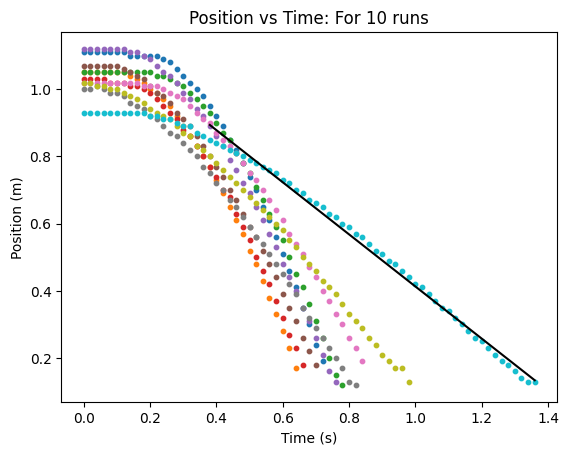

In [119]:
for i in range(1, 11):
    time = f"Time (s) Run #{i}"
    position = f"Position (m) Run #{i}"
    
    if time in clean_df.columns and position in clean_df.columns:
        data_piece = clean_df[[time, position]]
        
        plt.scatter(data_piece[time], data_piece[position], label=f"Run #{i}", s=10)   
        data = data_piece[data_piece[time].astype(float) >= data_piece[time].astype(float).max() - 1.0]
        
        time_values = data[time].astype(float)
        position_values = data[position].astype(float)
        
        slope, intercept = np.polyfit(time_values, position_values, 1)      
        plt.plot(time_values, slope * time_values + intercept, linestyle='-', color='black')

plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title("Position vs Time: For 10 runs")
plt.show()


### ${\color{green} \text{Submit your work to moodle and git for Part 1 before moving to Part 2}}$

## Part 2: experiment with multiple coffee filters, 10 runs
**Part 2 DUE DATE: Friday, February 14 at 20:00**

**Part 2 is worth 40% of Assignment #1**

#### Submission:
- Upload all new and updated files to moodle under ${\color{green}\text{Assignment \#1}}$.  Make sure to not delete or overwrite any files during your previous submissions.  
- `add`, `commit`, `push` all new and updated files to ${\color{green}\text{git}}$ in your **Assignment #1** folder
- late submissions of Part 2 will receive a grade of 0.


#### Instructions for Part 2:

1. Read  your .csv file that has the data of filters of varying mass into a DataFrame `df`.  
3. Display the content of the DataFrame to the screen

In [ ]:
# Your code for steps 1 and 2 go here:

3. Extract from the DataFrame `df` into a new DataFrame `data_df` only the **Time** and **Position** columns for the 10 runs.  Here are the details of how your `data_df` should look: 
- Time column titles should read: **Time (s) Run #$i$** for $0\leq i\leq 10$
- Position column titles should read: **Position (m) Run #$i$** for $0\leq i\leq 10$
- The order of the columns in your `data_df` should first display all the **Time** columns then all the **Position** columns.  
- all NaN values should be dropped from `data_df`
Note that this process should be automated.
4. Display the content of `data_df`

In [ ]:
# Your code for steps 3 and 4 go here:

5. The data in `data_df` contains noisy data.  In this step you are to clean the noisy data (or extract the clean data). Your cleaned data **for each run**
- must not include the data that is after once the filter hits the motion sensor
- must include only the bit where a drop in position starts.  You should not include any constant position values before the drop of positions takes place.    
Note that you should clean your data for each of the 10 runs and you should automate this process in your code with logical conditions, loops, etc.
6. Store your clean data into a new DataFrame called `clean_df`. 
7. Note that now that the values in the **Time** columns may have shifted due to the clean-up.  Update your `clean_df` to rescale all the **Time** columns to start the time from 0.0 in increments of 0.02. 
8. Write this to a new .csv file called `"clean_data_multiple_filter.csv"`. 

In [ ]:
# Your code for steps 5-8 go here:

9. Plot the data from all 10 runs as line plots on the same figure using your cleaned data.  
- Each plot should have a label **Run #$i$** for $1\leq i\leq10$
- The label on the x-axis should read **Time (s)**
- The label on the y-axis should read **Position (m)**
- Each plot should be in a different color and there should be a legend showing which colour is which run.  

In [ ]:
# Your code for step 9 goes here: